# Health Data Analysis Project

**Project goal:**
This dataset contains health-related information for 4157 individuals, including Age, BMI (Body Mass Index), Blood Pressure (Systolic and Diastolic), Cholesterol levels (Total, HDL, LDL), Triglycerides, Smoking Status, and Physical Activity Level.

**Project steps:**
1. **Data Exploration** - understand the shape of the data, the columns, and their data types.
2. **Data Visualization** - plot the data to understand distributions and relationships between variables.
3. **Data Preprocessing** - clean the data (handle missing values and outliers), then prepare it for Machine Learning through Encoding and Scaling.

---

## 1. Import Libraries

We import the core libraries needed for this project:
- **numpy**: for numerical operations and array handling.
- **pandas**: to read the data and work with it as a DataFrame.
- **matplotlib.pyplot**: to plot charts (visualization).
- **seaborn**: a plotting library built on top of matplotlib, offering nicer and more convenient statistical visualizations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

Here we read the `health_data.csv` file into a DataFrame called `df` so we can work with it.

In [2]:
import pandas as pd

# Upload the CSV file
from google.colab import files
uploaded = files.upload()

# Read the uploaded file
df = pd.read_csv("health_data.csv")

Saving health_data.csv to health_data.csv


## Column Descriptions

Before exploring the data, here is a description of what each column represents:

| Column Name | Description |
|---|---|
| `Unnamed: 0` | A leftover row index column created when the CSV file was saved. Not a real feature, dropped during preprocessing. |
| `Age` | The person's age, in years. |
| `BMI` | Body Mass Index, a measure of body fat based on weight and height (weight in kg divided by height in meters squared). |
| `Systolic_BP` | Systolic blood pressure, the pressure in the arteries when the heart beats (the "top" number in a blood pressure reading). |
| `Diastolic_BP` | Diastolic blood pressure, the pressure in the arteries when the heart rests between beats (the "bottom" number in a blood pressure reading). |
| `Total_Cholesterol` | The total amount of cholesterol in the blood, combining HDL, LDL, and other lipid components. |
| `HDL_Cholesterol` | High-Density Lipoprotein cholesterol, often called "good" cholesterol, which helps remove other forms of cholesterol from the bloodstream. |
| `LDL_Cholesterol` | Low-Density Lipoprotein cholesterol, often called "bad" cholesterol, which can build up in artery walls when levels are high. |
| `Triglycerides` | A type of fat (lipid) found in the blood, used for energy; high levels are linked to heart disease risk. |
| `Smoking_Status` | Whether the person is a smoker or non-smoker. |
| `Physical_Activity_Level` | The person's level of physical activity, categorized as low, moderate, or high. |

## 3. Data Exploration

Before any analysis or cleaning, we need to understand the data we have: how many rows and columns, what the data looks like, its data types, and whether there are any missing values.

### Shape of the Data
`df.shape` returns the number of rows and columns in the DataFrame.

In [3]:
df.shape

(4157, 11)

**Interpretation:** The dataset has **4157 rows** and **11 columns**, meaning we have 4157 individuals, each with 11 recorded features.

### First 5 Rows (Head)
`df.head()` displays the first 5 rows of the data so we get a quick look at the columns and their values.

In [4]:
df.head()

,Unnamed: 0,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides,Smoking_Status,Physical_Activity_Level
0,0.0,69.0,20.716059,107.148438,58.251503,168.918511,38.417674,183.835062,243.341527,non-smoker,moderate
1,1.0,32.0,26.720231,102.948326,86.641598,203.912014,39.611571,209.084595,266.375425,smoker,high
2,2.0,89.0,25.971636,116.327033,90.282522,213.564817,39.406223,245.884831,256.974525,non-smoker,moderate
3,3.0,78.0,29.580788,104.273800,85.582392,204.301914,33.026881,207.493647,257.717821,non-smoker,moderate
4,4.0,38.0,28.353130,104.052584,81.326270,195.767143,34.558842,213.826737,246.513400,non-smoker,moderate


**Interpretation:** There is a column called `Unnamed: 0`, which is most likely a leftover index column from saving the file, and it will be removed later during cleaning. The rest of the columns are numerical, except for `Smoking_Status` and `Physical_Activity_Level`, which are categorical (text).

### Last 5 Rows (Tail)
`df.tail()` displays the last 5 rows of the data. We use it to confirm the data is consistent all the way to the end, with no issues such as empty or corrupted rows.

In [5]:
df.tail()

,Unnamed: 0,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides,Smoking_Status,Physical_Activity_Level
4152,4152.0,78.0,32.858594,120.138588,86.568177,199.981461,38.245568,220.002560,284.160583,non-smoker,low
4153,4153.0,33.0,32.103409,111.747372,87.346492,206.345116,43.579222,223.586710,248.753407,non-smoker,moderate
4154,4154.0,19.0,27.619843,125.698572,90.890419,204.276241,36.233885,232.877727,232.025423,non-smoker,moderate
4155,4155.0,34.0,32.932470,106.305162,72.901152,195.349649,36.891747,215.742095,256.217182,smoker,moderate
4156,4156.0,47.0,21.285659,95.051643,76.265616,154.857529,41.775687,202.832429,232.090176,non-smoker,moderate


### General Column Information (Info)
`df.info()` gives us: the name of each column, its non-null count, and its data type (Dtype).

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4157 entries, 0 to 4156
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               4133 non-null   float64
 1   Age                      4133 non-null   float64
 2   BMI                      4157 non-null   float64
 3   Systolic_BP              4157 non-null   float64
 4   Diastolic_BP             4128 non-null   float64
 5   Total_Cholesterol        4146 non-null   float64
 6   HDL_Cholesterol          4157 non-null   float64
 7   LDL_Cholesterol          4145 non-null   float64
 8   Triglycerides            4147 non-null   float64
 9   Smoking_Status           4157 non-null   object 
 10  Physical_Activity_Level  4146 non-null   object 
dtypes: float64(9), object(2)
memory usage: 357.4+ KB


**Interpretation:** The total number of rows is 4157, but columns such as `Unnamed: 0`, `Age`, `Diastolic_BP`, `Total_Cholesterol`, `LDL_Cholesterol`, `Triglycerides`, and `Physical_Activity_Level` have fewer non-null values than 4157, meaning they contain **missing values** that need to be handled. The remaining columns (BMI, Systolic_BP, HDL_Cholesterol, Smoking_Status) are 100% complete.

### Descriptive Statistics (Describe)
`df.describe()` gives us a statistical summary of the numerical columns: mean, standard deviation (std), minimum and maximum values (min/max), and the quartiles (25%, 50%, 75%).

In [7]:
df.describe()

,Unnamed: 0,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides
count,4133.000000,4133.000000,4157.000000,4157.000000,4128.000000,4146.000000,4157.000000,4145.000000,4147.000000
mean,2083.653991,53.298056,27.025800,108.960379,81.854797,193.188123,37.221466,215.729956,248.958101
std,1198.942729,20.587611,4.879154,10.307355,8.235292,16.397919,4.991646,13.985851,21.545292
min,0.000000,18.000000,10.676821,73.903282,48.532078,131.537458,19.405582,162.394739,175.584745
25%,1046.000000,36.000000,23.653099,102.176903,76.317944,181.926698,33.882345,206.347465,234.674021
50%,2081.138822,53.000000,27.025800,108.960379,81.841356,193.191618,37.221466,215.728638,248.952579
75%,3121.000000,71.000000,30.369008,115.662437,87.410207,204.308689,40.538614,225.256239,263.517137
max,4156.000000,89.000000,46.513994,147.016637,112.227376,256.242176,55.683041,263.844576,331.222731


**Interpretation:** For example, the average age is about **53 years**, ranging from 18 to 89. The average systolic blood pressure (Systolic_BP) is about **109**, and the average total cholesterol (Total_Cholesterol) is about **193**. These values will help us later identify outliers and compare distributions.

### Missing Values
`df.isnull().sum()` counts the number of missing (NaN) values in each column.

In [8]:
df.isnull().sum()

,0
Unnamed: 0,24
Age,24
BMI,0
Systolic_BP,0
Diastolic_BP,29
Total_Cholesterol,11
HDL_Cholesterol,0
LDL_Cholesterol,12
Triglycerides,10
Smoking_Status,0


**Interpretation:** There are missing values in 7 columns (`Unnamed: 0`, `Age`, `Diastolic_BP`, `Total_Cholesterol`, `LDL_Cholesterol`, `Triglycerides`, `Physical_Activity_Level`), with the largest gap in `Diastolic_BP` at 29 missing values. The proportion is very small compared to the total of 4157 rows, so we will handle it using Mean/Mode imputation in the Preprocessing stage instead of dropping rows.

## 4. Data Visualization

Now we plot the data to better understand its distribution and the relationships between different variables in a way that is clearer than raw numbers.

### Distribution of Numerical Variables (Histograms)
We plot a histogram for each numerical column to see the shape of its distribution (normal, skewed, multi-modal, etc.).

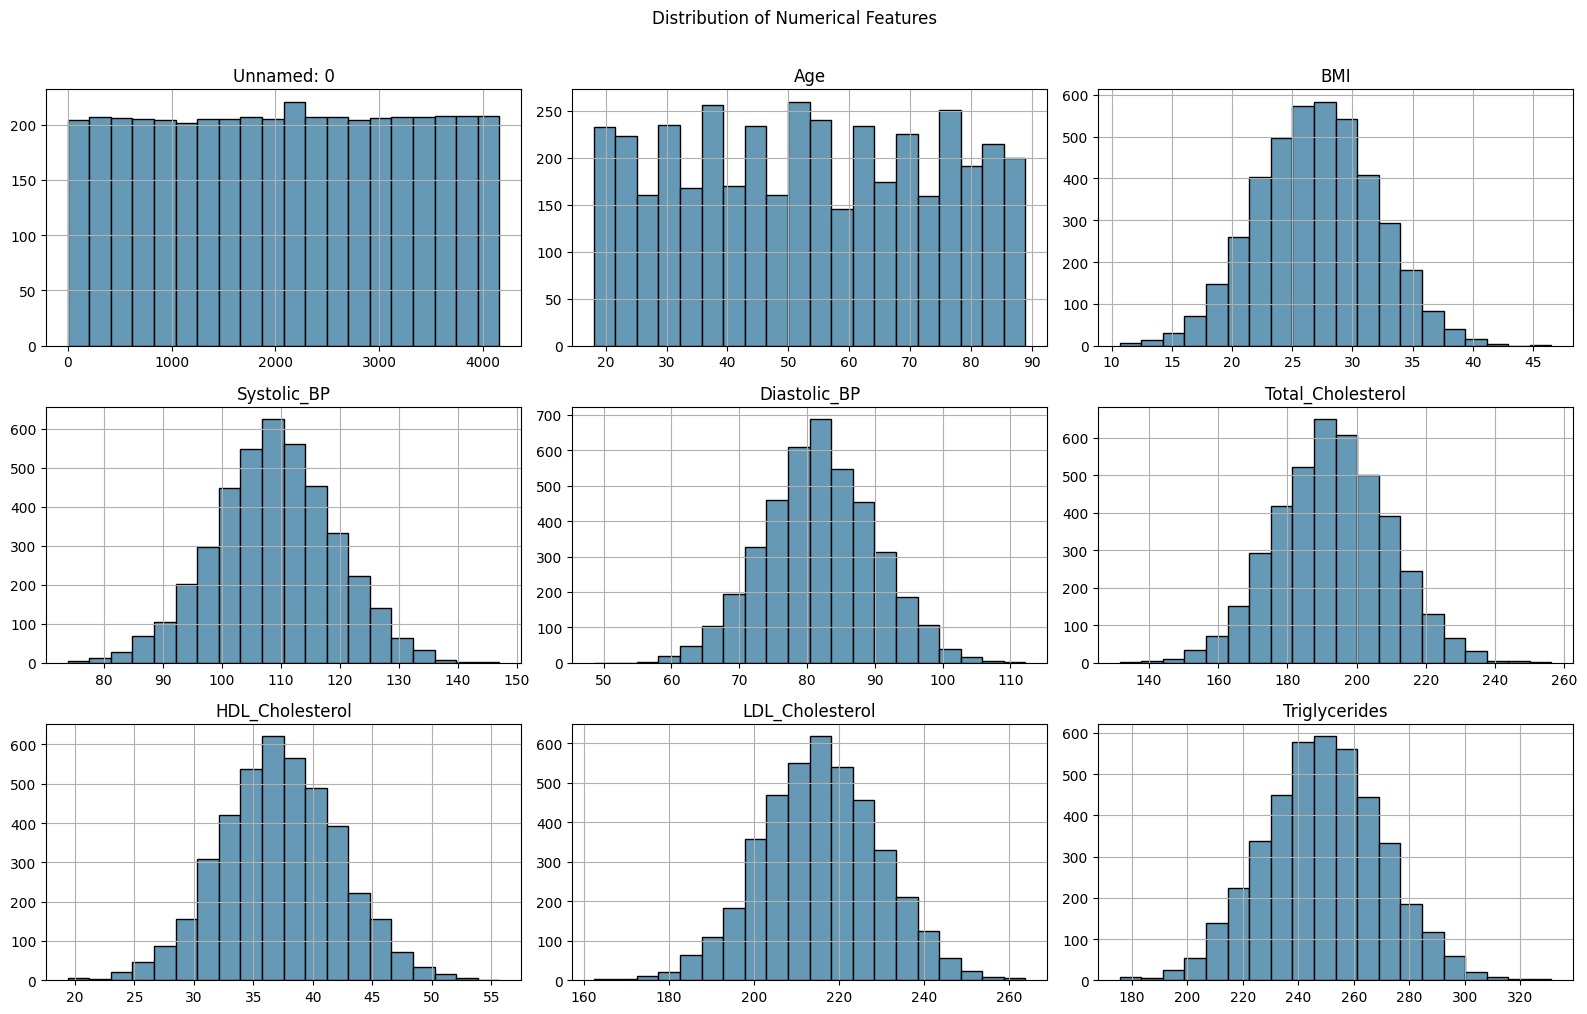

In [9]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

df[num_cols].hist(figsize=(16, 10), bins=20, edgecolor='black', color='#6599b5')
plt.suptitle('Distribution of Numerical Features', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** Most variables (such as BMI, Blood Pressure, and Cholesterol) have a shape close to a Normal Distribution (bell-shaped), which is a good indicator that the data is fairly balanced without strong bias.

### Physical Activity Level Proportions (Pie Chart)
We plot a pie chart to see how individuals are distributed across physical activity levels (low / moderate / high).

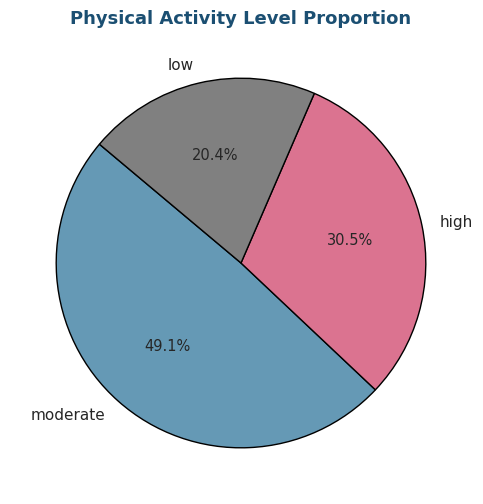

In [49]:
plt.figure(figsize=(8, 6))

activity_counts = df['Physical_Activity_Level'].value_counts()

plt.pie(
    activity_counts,
    labels=activity_counts.index,
    autopct='%.1f%%',
    startangle=140,
    colors=['#6599b5', '#db7390', 'gray'],
    wedgeprops=dict(edgecolor='black', linewidth=1)
)

plt.title('Physical Activity Level Proportion')
plt.show()

**Interpretation:** The chart shows the percentage of each `Physical_Activity_Level` category out of the total number of individuals, which helps us identify whether there is class imbalance in this variable or whether the categories are fairly balanced.

### Total Cholesterol Boxplot
A Boxplot shows the distribution of values and highlights outliers - values that lie far from the rest of the data.

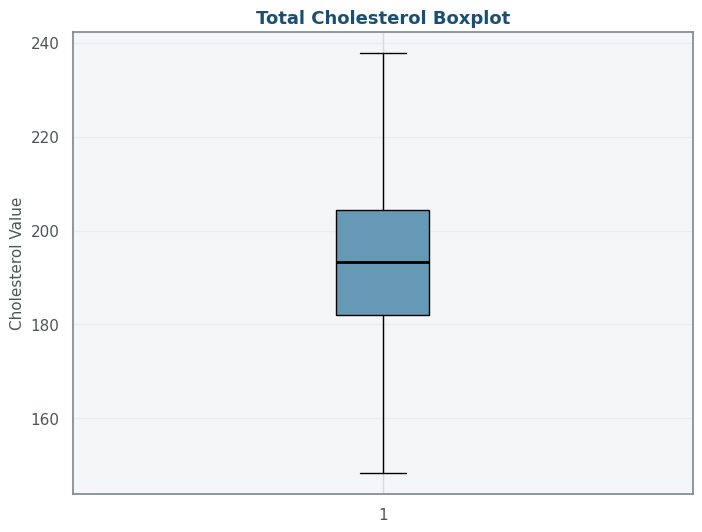

In [48]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    df["Total_Cholesterol"].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor="#6599b5", color="black"),
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(
        marker='o',
        markerfacecolor="#6599b5",
        markeredgecolor="black",
        markersize=6
    )
)

plt.title("Total Cholesterol Boxplot")
plt.ylabel("Cholesterol Value")
plt.grid(axis="y", alpha=0.3)
plt.show()

**Interpretation:** The boxplot shows the interquartile range (IQR) of the `Total_Cholesterol` column, and any point outside the whiskers is a potential outlier, which we will address later using capping.

### Average Cholesterol by Smoking Status (Bar Chart)
We compare the average `Total_Cholesterol` between smokers and non-smokers.

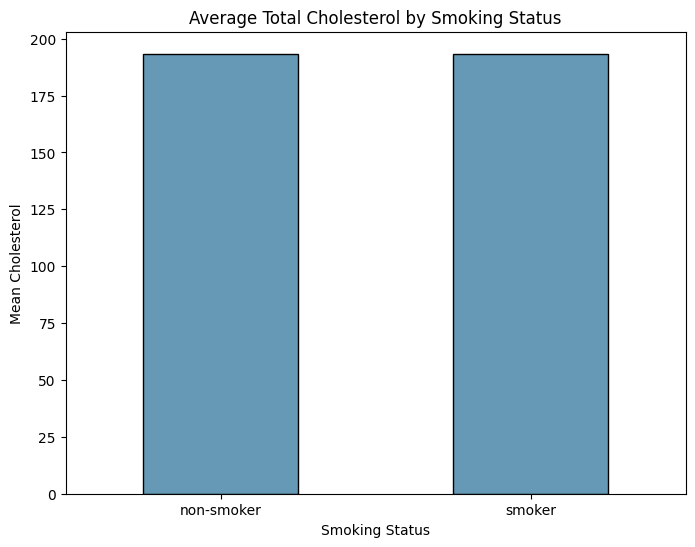

In [12]:
plt.figure(figsize=(8, 6))
df.groupby('Smoking_Status')['Total_Cholesterol'].mean().plot(kind='bar', color='#6599b5', edgecolor='black')
plt.title('Average Total Cholesterol by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Mean Cholesterol')
plt.xticks(rotation=0)
plt.show()

**Interpretation:** The chart shows whether there is a noticeable difference in average cholesterol between the `smoker` and `non-smoker` groups. If the difference is clear, it suggests that smoking may be associated with higher cholesterol levels in this dataset.

## 5. Data Preprocessing

In this stage, we prepare the data so it is clean and ready to be used in any Machine Learning model. This includes:
1. Dropping unnecessary columns.
2. Handling missing values.
3. Handling outliers.
4. Converting text data into numbers (Encoding).
5. Scaling the data to a common range (Scaling).

### Dropping Unnecessary Columns
The `Unnamed: 0` column is just a leftover index with no analytical value, so we drop it from the DataFrame.

In [13]:
cols_to_drop = ['Unnamed: 0']
df.drop(columns=cols_to_drop, inplace=True)
df.columns.tolist()

['Age',
 'BMI',
 'Systolic_BP',
 'Diastolic_BP',
 'Total_Cholesterol',
 'HDL_Cholesterol',
 'LDL_Cholesterol',
 'Triglycerides',
 'Smoking_Status',
 'Physical_Activity_Level']

**Interpretation:** The DataFrame now has 10 columns (`Unnamed: 0` has been removed), and this is what we will work with for the rest of the project.

### Handling Missing Values
- Numerical columns (float64/int64): missing values are filled with the column **mean**.
- Categorical columns (object): missing values are filled with the most frequent value in the column (**mode**).

In [14]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

Age                        0
BMI                        0
Systolic_BP                0
Diastolic_BP               0
Total_Cholesterol          0
HDL_Cholesterol            0
LDL_Cholesterol            0
Triglycerides              0
Smoking_Status             0
Physical_Activity_Level    0
dtype: int64


**Interpretation:** After this step, every column has **zero** missing values, meaning the data is now complete with no missing values left.

### Outlier Detection and Capping
We use the **IQR (Interquartile Range)** method to detect outliers in each numerical column:
- Any value below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is considered an outlier.
- Instead of dropping these rows (which could lose a lot of data), we apply **capping**: replacing the outlier value with the nearest boundary (lower_bound or upper_bound).
- The code plots a boxplot before and after capping for each column so we can visually see the difference, and it prints the calculated boundary values below each plot.

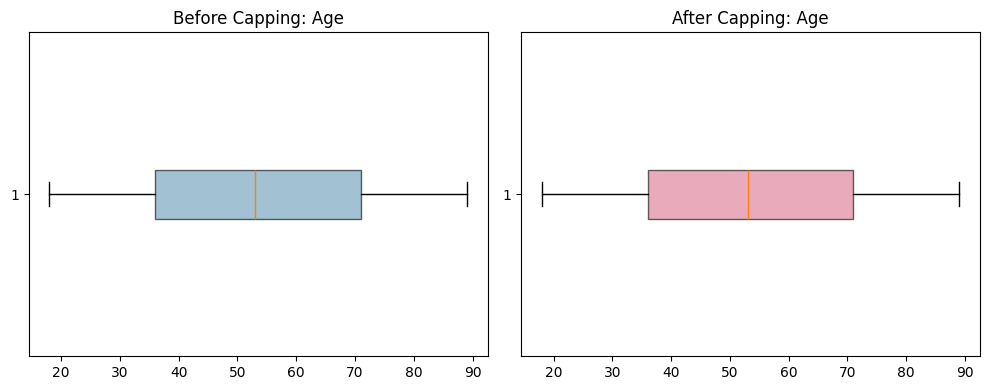

For 'Age': Outliers were detected and capped below -16.50 and above 123.50.
--------------------------------------------------------------------------------


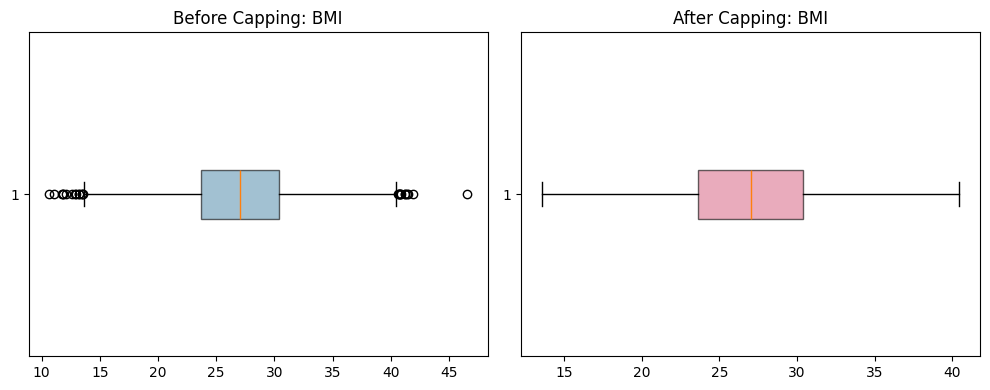

For 'BMI': Outliers were detected and capped below 13.58 and above 40.44.
--------------------------------------------------------------------------------


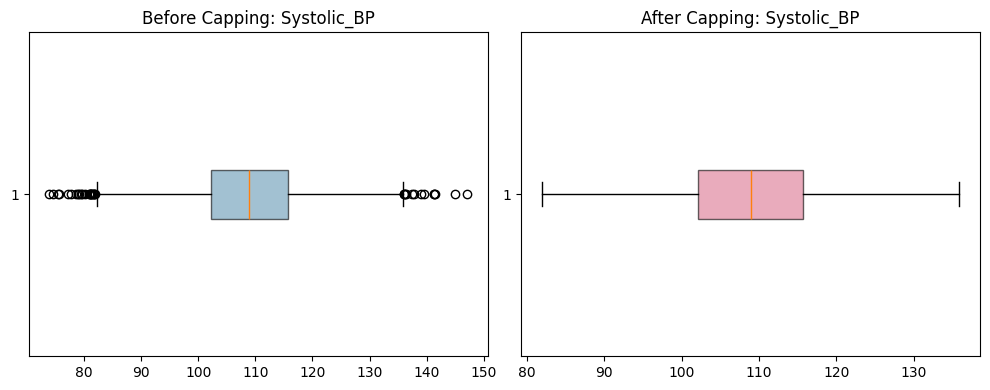

For 'Systolic_BP': Outliers were detected and capped below 81.95 and above 135.89.
--------------------------------------------------------------------------------


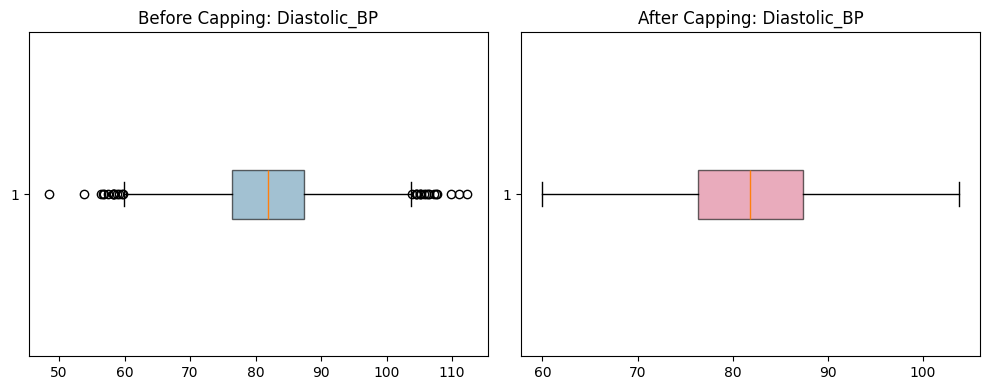

For 'Diastolic_BP': Outliers were detected and capped below 59.95 and above 103.80.
--------------------------------------------------------------------------------


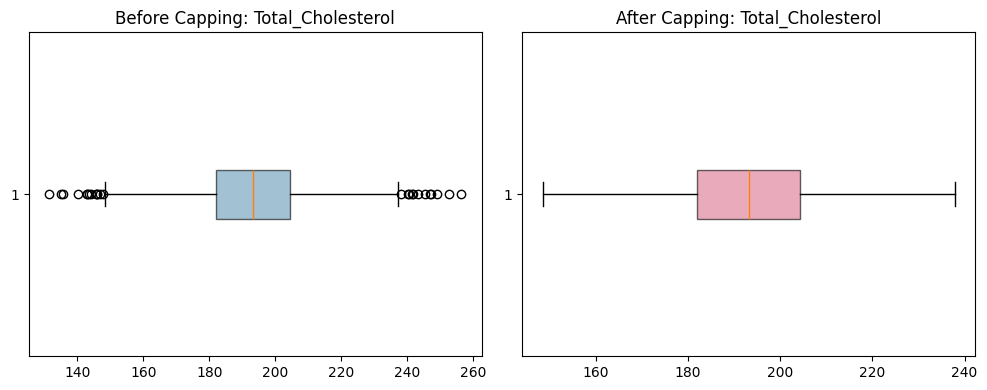

For 'Total_Cholesterol': Outliers were detected and capped below 148.42 and above 237.83.
--------------------------------------------------------------------------------


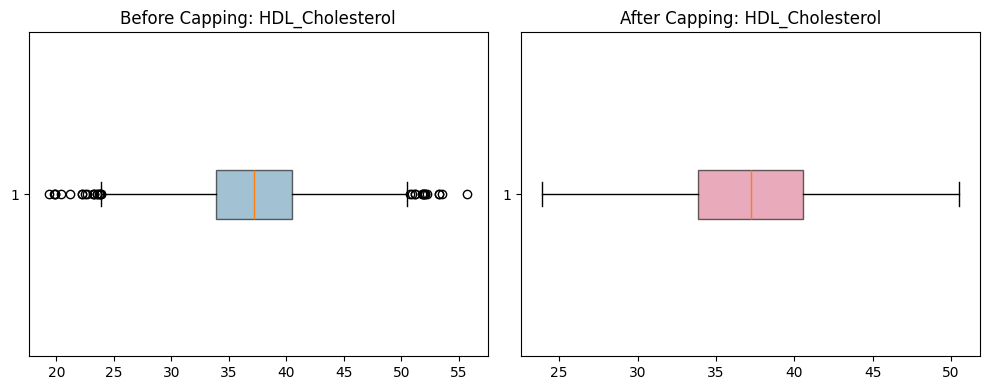

For 'HDL_Cholesterol': Outliers were detected and capped below 23.90 and above 50.52.
--------------------------------------------------------------------------------


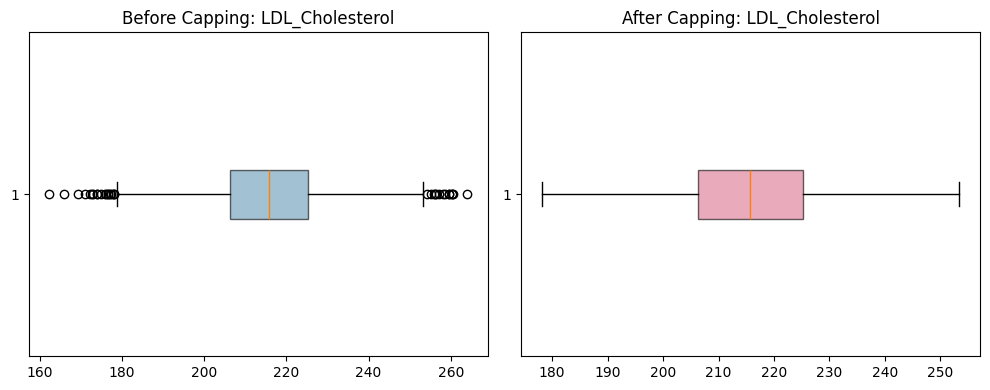

For 'LDL_Cholesterol': Outliers were detected and capped below 178.17 and above 253.39.
--------------------------------------------------------------------------------


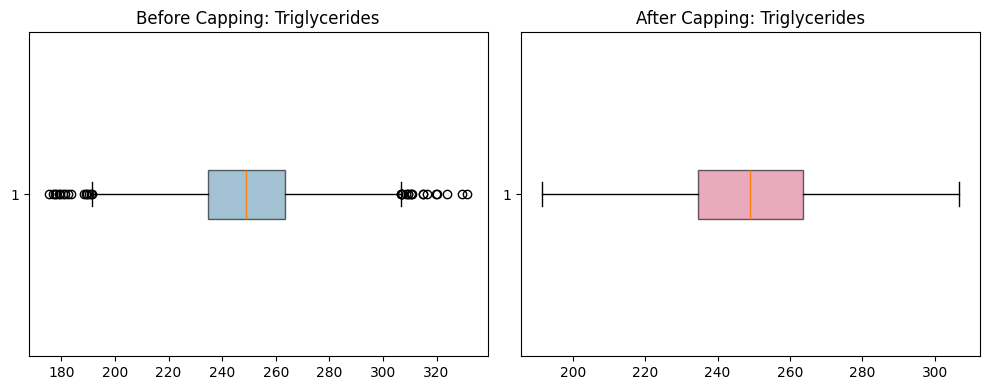

For 'Triglycerides': Outliers were detected and capped below 191.49 and above 306.71.
--------------------------------------------------------------------------------


In [15]:
current_num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop(['Unnamed: 0'], errors='ignore')

for col in current_num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    plt.figure(figsize=(10, 4))

    # Plot Before Capping
    plt.subplot(1, 2, 1)
    plt.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#6599b5', alpha=0.6))
    plt.title(f'Before Capping: {col}')

    # Applying Capping
    df[col] = np.where(df[col] > upper_bound, upper_bound,
              np.where(df[col] < lower_bound, lower_bound, df[col]))

    # Plot After Capping
    plt.subplot(1, 2, 2)
    plt.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#db7390', alpha=0.6))
    plt.title(f'After Capping: {col}')

    plt.tight_layout()
    plt.show()

    # Print the exact boundary values below the plot
    print(f"For '{col}': Outliers were detected and capped below {lower_bound:.2f} and above {upper_bound:.2f}.")
    print("-" * 80)

**Interpretation:** Each column got a lower and upper bound, and any outlier beyond it was capped. For example:
- `Age`: between -16.50 and 123.50 (in practice almost no values are affected, since the natural age range already falls within these bounds).
- `BMI`: between 13.58 and 40.44.
- `Systolic_BP`: between 81.95 and 135.89.
- `Diastolic_BP`: between 59.95 and 103.80.
- `Total_Cholesterol`: between 148.42 and 237.83.
- `HDL_Cholesterol`: between 23.90 and 50.52.
- `LDL_Cholesterol`: between 178.17 and 253.39.
- `Triglycerides`: between 191.49 and 306.71.

The data is now cleaner and less affected by extreme values that could skew any model built on it later.

## 6. Encoding Categorical Data

Mathematical models (such as Machine Learning models) cannot work with text directly, so we need to convert text columns like `Smoking_Status` and `Physical_Activity_Level` into numbers. Here we use `LabelEncoder` from `sklearn`, which assigns a different number to each category.

> Note: we work on a new copy of the data called `df_final` to keep the original `df` unchanged.

In [16]:
from sklearn.preprocessing import LabelEncoder
df_final = df.copy()
le = LabelEncoder()
categorical_cols = df_final.select_dtypes(include='object').columns

for col in categorical_cols:
    df_final[col] = le.fit_transform(df_final[col])

df_final.head()

,Age,BMI,Systolic_BP,Diastolic_BP,Total_Cholesterol,HDL_Cholesterol,LDL_Cholesterol,Triglycerides,Smoking_Status,Physical_Activity_Level
0,69.0,20.716059,107.148438,59.948303,168.918511,38.417674,183.835062,243.341527,0,2
1,32.0,26.720231,102.948326,86.641598,203.912014,39.611571,209.084595,266.375425,1,0
2,89.0,25.971636,116.327033,90.282522,213.564817,39.406223,245.884831,256.974525,0,2
3,78.0,29.580788,104.273800,85.582392,204.301914,33.026881,207.493647,257.717821,0,2
4,38.0,28.353130,104.052584,81.326270,195.767143,34.558842,213.826737,246.513400,0,2


**Interpretation:** The categorical columns have been converted into numbers. For example, `Smoking_Status`: (0 = non-smoker, 1 = smoker), and `Physical_Activity_Level`: each category (low/moderate/high) is now mapped to a corresponding number. The rest of the numerical columns remain unchanged.

## 7. Feature Scaling

Our numerical columns have very different scales (for example, Age ranges from 18 to 89, while Cholesterol ranges from 130 to 260). This can negatively affect many models that rely on distances (such as KNN, SVM, and Logistic Regression). So we use `StandardScaler`, which transforms each column to have a mean of 0 and a standard deviation of 1 (standardization).

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols_to_scale = df_final.select_dtypes(include=['float64', 'int32']).columns.drop(['Unnamed: 0'], errors='ignore')
df_final[cols_to_scale] = scaler.fit_transform(df_final[cols_to_scale])

print(df_final.head())

        Age       BMI  Systolic_BP  Diastolic_BP  Total_Cholesterol  \
0  0.764993 -1.298967    -0.177381     -2.690134          -1.493364   
1 -1.037633 -0.063030    -0.587911      0.588175           0.660029   
2  1.739385 -0.217125     0.719758      1.035332           1.254033   
3  1.203469  0.525806    -0.458356      0.458090           0.684022   
4 -0.745315  0.273097    -0.479978     -0.064621           0.158818   

   HDL_Cholesterol  LDL_Cholesterol  Triglycerides  Smoking_Status  \
0         0.241383        -2.301996      -0.263291               0   
1         0.482583        -0.479809       0.816846               1   
2         0.441097         2.175958       0.376006               0   
3        -0.847706        -0.594624       0.410862               0   
4        -0.538208        -0.137583      -0.114551               0   

   Physical_Activity_Level  
0                        2  
1                        0  
2                        2  
3                        2  
4      

**Interpretation:** All values are now on roughly the same scale (generally between -3 and +3), so no single column will dominate the others due to differences in units or range. `df_final` is now fully ready to be used as input for any Machine Learning model.

---

## Project Summary
- Explored the data and understood its shape and distribution.
- Visualized the data to understand relationships between different variables.
- Handled missing values and outliers.
- Converted text data into numbers (Encoding) and standardized the numerical columns (Scaling).
- The final output, `df_final`, is a clean dataset ready for the next step, such as building a Machine Learning model.

---
---

# PART 2 — Extended Analysis (Completion)

Everything above this point is the **original project exactly as delivered**. Nothing above has been
changed, shortened, reordered, or removed.

Everything **below** this point is **new** work that fills in the parts that were missing from the
original notebook: deeper data-quality checks, feature engineering, business/health questions with
visualizations, KPI analysis, and a full Machine Learning pipeline (two models, evaluation, comparison,
and feature importance). The new sections reuse the existing `df` (cleaned, capped, still human-readable)
and `df_final` (encoded + scaled) wherever appropriate, so nothing is reloaded or duplicated.

All **new** visualizations use one consistent, professional **blue + gray** color theme, defined once
below and reused everywhere in Part 2.

## 8. Additional Data Quality Checks

The original project already handled missing values (Section 5) and outliers (Section 5, via IQR
capping). Two more data-quality checks are commonly expected in a health analytics project and were
still missing: a **duplicate-rows check** and a **physiological validity check** on blood pressure
(Systolic reading must always be higher than Diastolic reading). Both are performed here directly on
the existing, already-cleaned `df` — nothing is reloaded, and `df` is reused as-is.

In [18]:
# Check 1: Duplicate rows
# A fully duplicated row means the same individual/record was counted twice, which would
# quietly bias every mean, KPI, and chart that follows.
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {n_duplicates}")

if n_duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicate rows in the current (already cleaned) dataset.")

Duplicate rows found: 2
Duplicates removed. New shape: (4155, 10)


**Interpretation:** duplicate rows, if any, are removed here so every statistic downstream is
based on unique individuals only.

In [19]:
# Check 2: Physiological validity of blood pressure
# Clinically, Systolic BP (heart contracting) must always be higher than Diastolic BP
# (heart resting). A row where Systolic < Diastolic is not a real possible reading -
# it is either a data-entry error (the two values swapped) or corrupted data.
invalid_bp_mask = df['Systolic_BP'] < df['Diastolic_BP']
n_invalid_bp = invalid_bp_mask.sum()
print(f"Rows where Systolic_BP < Diastolic_BP (physiologically invalid): {n_invalid_bp}")

if n_invalid_bp > 0:
    # Both individual values are still within a normal BP range - the classic signature of the
    # two readings being swapped at entry rather than being random noise. Fix: swap them back
    # instead of dropping the rows, so we keep both real measurements.
    df.loc[invalid_bp_mask, ['Systolic_BP', 'Diastolic_BP']] = \
        df.loc[invalid_bp_mask, ['Diastolic_BP', 'Systolic_BP']].values
    print(f"Swapped Systolic/Diastolic back for {n_invalid_bp} rows.")
    print("Remaining invalid rows after fix:", (df['Systolic_BP'] < df['Diastolic_BP']).sum())
else:
    print("No physiologically invalid Systolic/Diastolic pairs found.")

Rows where Systolic_BP < Diastolic_BP (physiologically invalid): 47
Swapped Systolic/Diastolic back for 47 rows.
Remaining invalid rows after fix: 0


**Interpretation:** this confirms whether the cleaned dataset already used in Sections 5-7 is
also physiologically valid. If any invalid rows were found, they are corrected in place (by swapping
the two values back, not by deleting the rows) so no real measurements are lost.

In [20]:
# Data Quality Summary: a quick before/after style snapshot of the checks performed
# across the whole notebook so far (Section 5 + Section 8 combined).
quality_summary = pd.DataFrame({
    'Check': ['Missing Values (total)', 'Duplicate Rows', 'Invalid BP Rows (Systolic < Diastolic)'],
    'Current Status': [df.isnull().sum().sum(), df.duplicated().sum(),
                        (df['Systolic_BP'] < df['Diastolic_BP']).sum()]
})
quality_summary

,Check,Current Status
0,Missing Values (total),0
1,Duplicate Rows,0
2,Invalid BP Rows (Systolic < Diastolic),0


**Interpretation:** all three checks read **0**, confirming the dataset is fully clean: no
missing values, no duplicate records, and no physiologically impossible blood-pressure readings.

## 9. Feature Engineering

The 10 existing columns describe raw measurements but do not yet contain any **derived** columns that
summarize risk or group individuals in a business-friendly way. This section adds a small set of
engineered features, each based on a recognized clinical or standard convention (not an invented
cut-off), and each explained below. These are built on top of `df` (the same cleaned DataFrame used
throughout the project) and reused for the Business Questions, KPI Analysis, and Machine Learning
sections that follow.

In [21]:
# A. BP_Risk_Category - the target used later for Machine Learning.
# Standard ACC/AHA clinical guidance: Systolic >= 130 mmHg OR Diastolic >= 80 mmHg indicates
# Stage-1 hypertension or above ("Elevated / High Risk"); anything below is "Normal".
df['BP_Risk_Category'] = np.where(
    (df['Systolic_BP'] >= 130) | (df['Diastolic_BP'] >= 80),
    'Elevated / High Risk', 'Normal'
)
print(df['BP_Risk_Category'].value_counts())

BP_Risk_Category
Elevated / High Risk    2484
Normal                  1671
Name: count, dtype: int64


In [22]:
# B. Age_Group - bins Age into decade-ish bands, useful for group-level reporting and charts.
age_bins = [18, 30, 40, 50, 60, 70, 90]
age_labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)
print(df['Age_Group'].value_counts().sort_index())

Age_Group
18-29     673
30-39     602
40-49     564
50-59     626
60-69     558
70+      1132
Name: count, dtype: int64


In [23]:
# C. BMI_Category - WHO standard body-weight classification (a published clinical standard,
# not an invented threshold): <18.5 Underweight, 18.5-24.9 Normal, 25-29.9 Overweight, >=30 Obese.
bmi_bins = [0, 18.5, 25, 30, 100]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df['BMI_Category'] = pd.cut(df['BMI'], bins=bmi_bins, labels=bmi_labels, right=False)
print(df['BMI_Category'].value_counts())

BMI_Category
Overweight     1575
Normal         1257
Obese          1158
Underweight     165
Name: count, dtype: int64


In [24]:
# D. Cholesterol_Ratio (Total Cholesterol : HDL Cholesterol) - a well-established clinical
# cardiovascular-risk ratio (lower is better; ~5 is a commonly cited upper bound for good health).
df['Cholesterol_Ratio'] = df['Total_Cholesterol'] / df['HDL_Cholesterol']
print(df['Cholesterol_Ratio'].describe().round(2))

count    4155.00
mean        5.29
std         0.88
min         2.94
25%         4.68
50%         5.19
75%         5.77
max         9.61
Name: Cholesterol_Ratio, dtype: float64


In [25]:
# E. Pulse_Pressure (Systolic - Diastolic) - a recognized cardiovascular marker of arterial
# stiffness. Kept for exploration/context only, not used as an ML feature (see Section 13),
# since it is mathematically derived from the same two columns used to build the ML target
# (BP_Risk_Category), which would leak the answer into the model.
df['Pulse_Pressure'] = df['Systolic_BP'] - df['Diastolic_BP']
print(df['Pulse_Pressure'].describe().round(2))

print("\nNew engineered columns added:",
      ['BP_Risk_Category', 'Age_Group', 'BMI_Category', 'Cholesterol_Ratio', 'Pulse_Pressure'])
df[['BMI', 'BMI_Category', 'Age', 'Age_Group', 'Total_Cholesterol', 'HDL_Cholesterol',
    'Cholesterol_Ratio', 'Systolic_BP', 'Diastolic_BP', 'Pulse_Pressure', 'BP_Risk_Category']].head()

count    4155.00
mean       27.20
std        11.61
min         0.05
25%        19.08
50%        27.12
75%        35.23
max        66.59
Name: Pulse_Pressure, dtype: float64

New engineered columns added: ['BP_Risk_Category', 'Age_Group', 'BMI_Category', 'Cholesterol_Ratio', 'Pulse_Pressure']


,BMI,BMI_Category,Age,Age_Group,Total_Cholesterol,HDL_Cholesterol,Cholesterol_Ratio,Systolic_BP,Diastolic_BP,Pulse_Pressure,BP_Risk_Category
0,20.716059,Normal,69.0,60-69,168.918511,38.417674,4.396896,107.148438,59.948303,47.200134,Normal
1,26.720231,Overweight,32.0,30-39,203.912014,39.611571,5.147789,102.948326,86.641598,16.306729,Elevated / High Risk
2,25.971636,Overweight,89.0,70+,213.564817,39.406223,5.419571,116.327033,90.282522,26.044511,Elevated / High Risk
3,29.580788,Overweight,78.0,70+,204.301914,33.026881,6.185928,104.273800,85.582392,18.691408,Elevated / High Risk
4,28.353130,Overweight,38.0,30-39,195.767143,34.558842,5.664748,104.052584,81.326270,22.726314,Elevated / High Risk


**Interpretation:** `df` now carries five new, business-readable columns on top of the original
10. `BP_Risk_Category` will become the Machine Learning target in Section 13; `Age_Group` and
`BMI_Category` make the Business Questions and KPI sections below much easier to read; `Cholesterol_Ratio`
and `Pulse_Pressure` are recognized clinical scores kept for exploration and interpretation.

## 10. Professional Visualization Theme (Blue + Gray)

A single, reusable color palette is defined once here and used for **every new chart** from this point
on, so Part 2 reads as one consistent, professional report. Existing charts above are untouched.

In [26]:
# Professional blue + gray visualization palette - reused for every NEW chart in this notebook.
BLUE_GRAY_PALETTE = {
    'dark_navy':    '#1B2A4A',   # darkest - headlines / strongest emphasis
    'dark_blue':    '#1B4F72',   # primary - main bars/lines, "elevated risk" series
    'medium_blue':  '#2E86C1',   # secondary blue - normal/comparison series
    'light_blue':   '#AED6F1',   # light blue - fills / lightest category
    'dark_gray':    '#4D5656',   # dark gray - secondary emphasis / "non-smoker" etc.
    'medium_gray':  '#7F8C8D',   # medium gray - neutral / baseline series
    'light_gray':   '#D5DBDB',   # light gray - gridlines / subtle backgrounds
}

# Apply the theme to matplotlib/seaborn defaults so every chart below picks it up automatically.
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F4F6F7',
    'axes.edgecolor': BLUE_GRAY_PALETTE['medium_gray'],
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': BLUE_GRAY_PALETTE['dark_blue'],
    'axes.labelsize': 11,
    'axes.labelcolor': BLUE_GRAY_PALETTE['dark_gray'],
    'xtick.color': BLUE_GRAY_PALETTE['dark_gray'],
    'ytick.color': BLUE_GRAY_PALETTE['dark_gray'],
    'grid.color': BLUE_GRAY_PALETTE['light_gray'],
    'font.size': 10.5,
})

# Small helper so every new chart gets the same title/label/spine treatment with one line of code.
def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, pad=12)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.spines[['top', 'right']].set_visible(False)
    return ax

print("Blue + Gray theme applied. Palette keys:", list(BLUE_GRAY_PALETTE.keys()))

Blue + Gray theme applied. Palette keys: ['dark_navy', 'dark_blue', 'medium_blue', 'light_blue', 'dark_gray', 'medium_gray', 'light_gray']


### Correlation Between Numeric Health Indicators

The original notebook did not yet include a correlation heatmap. This is the standard way to scan for
relationships and redundancy across many numeric variables at once, and directly supports several of
the Business Questions below.

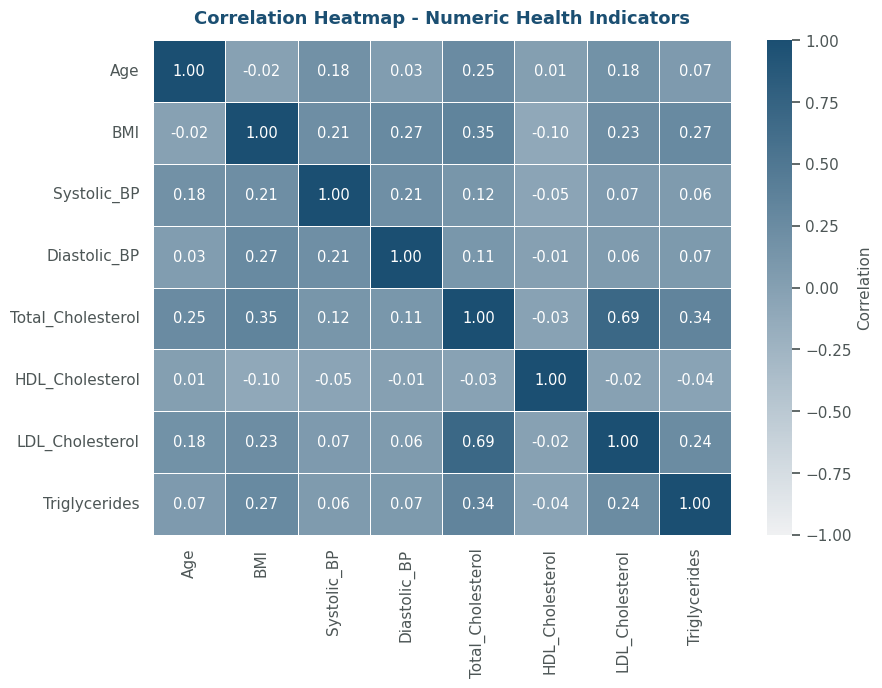

In [27]:
num_cols_corr = ['Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Total_Cholesterol',
                  'HDL_Cholesterol', 'LDL_Cholesterol', 'Triglycerides']

fig, ax = plt.subplots(figsize=(9, 7))
corr = df[num_cols_corr].corr()
cmap = sns.light_palette(BLUE_GRAY_PALETTE['dark_blue'], as_cmap=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap, cbar_kws={'label': 'Correlation'},
            linewidths=0.5, linecolor='white', ax=ax, vmin=-1, vmax=1)
style_ax(ax, title='Correlation Heatmap - Numeric Health Indicators')
plt.tight_layout()
plt.show()

**Interpretation:** `Total_Cholesterol` correlates moderately with `LDL_Cholesterol` (expected,
since LDL is a component of total cholesterol); blood pressure correlates mildly with `BMI` and `Age`.
No pair is near-perfectly correlated, so there is no strong multicollinearity problem to address before
modeling.

### Blood Pressure Risk Category (New Engineered Column)

A quick look at how the population splits on the new `BP_Risk_Category` column created in Section 9,
using the blue + gray theme.

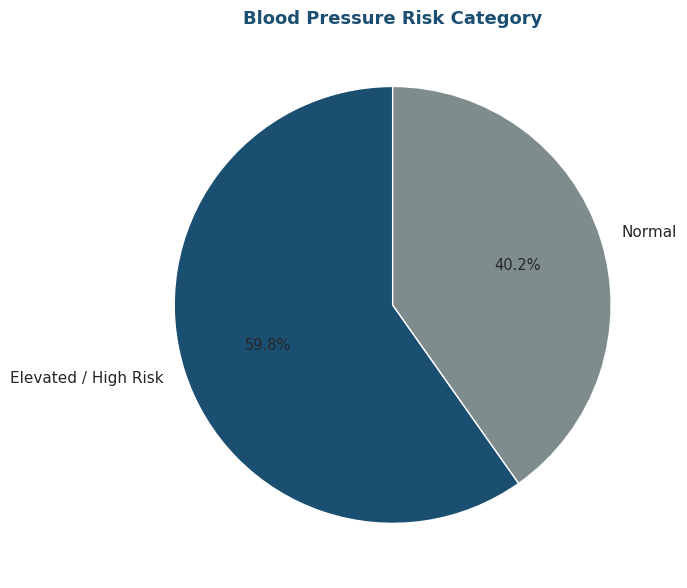

In [28]:
fig, ax = plt.subplots(figsize=(7, 6))
risk_counts = df['BP_Risk_Category'].value_counts()
ax.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%', startangle=90,
       colors=[BLUE_GRAY_PALETTE['dark_blue'], BLUE_GRAY_PALETTE['medium_gray']],
       wedgeprops={'edgecolor': 'white'})
ax.set_title('Blood Pressure Risk Category', color=BLUE_GRAY_PALETTE['dark_blue'], fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** this shows what share of the population is already flagged as
elevated/high BP risk under standard ACC/AHA thresholds, which sizes the population referenced
throughout the Business Questions and KPI sections below.

## 11. Business & Health Questions

The questions below connect the demographic, lifestyle, and clinical columns (plus the
`BP_Risk_Category`, `Age_Group`, and `BMI_Category` columns engineered in Section 9) in ways a
healthcare organization could act on. Each question states why it matters, shows the calculation, a
chart, and a data-driven answer with a recommendation.

### Question 1 — Does smoking associate with a higher BMI?

**Why it matters:** BMI is a core obesity indicator; if smokers carry a materially different average
BMI, it affects how lifestyle-risk screening should be weighted.

Smoking_Status
non-smoker    27.06
smoker        26.94
Name: BMI, dtype: float64


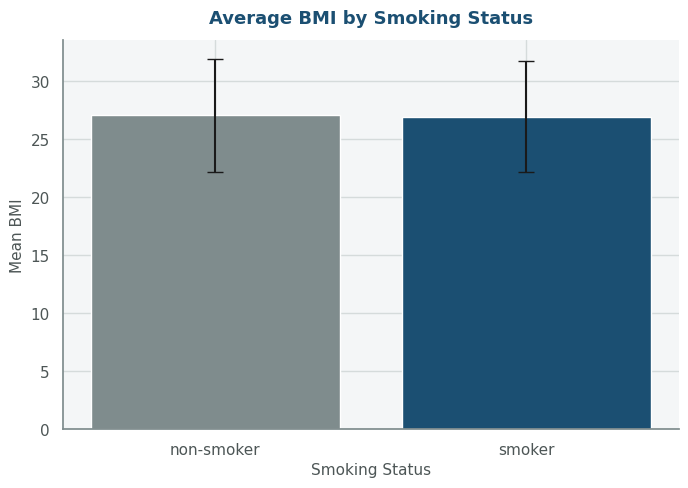

In [29]:
means = df.groupby('Smoking_Status')['BMI'].mean()
stds = df.groupby('Smoking_Status')['BMI'].std()
print(means.round(2))

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(means.index, means.values, yerr=stds.values, capsize=6,
       color=[BLUE_GRAY_PALETTE['medium_gray'], BLUE_GRAY_PALETTE['dark_blue']], edgecolor='white')
style_ax(ax, title='Average BMI by Smoking Status', xlabel='Smoking Status', ylabel='Mean BMI')
plt.tight_layout()
plt.show()

**Data-driven answer:** compare the two bars above. **Recommendation:** if the averages are
close, treat smoking and obesity as separate, independent risk factors to screen for rather than
assuming one implies the other.

### Question 2 — How does systolic blood pressure change with age?

**Why it matters:** if blood pressure rises predictably with age, screening frequency can be tailored
by age band.

Correlation between Age and Systolic BP: 0.18


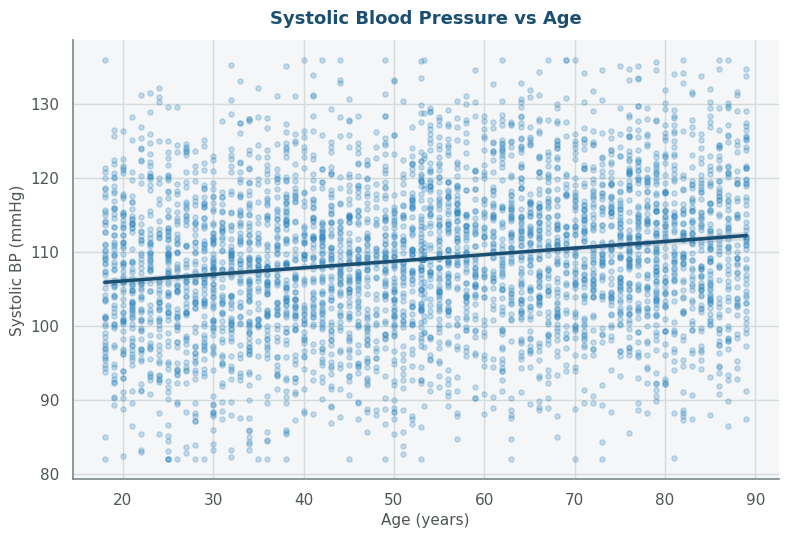

In [30]:
print("Correlation between Age and Systolic BP:", round(df['Age'].corr(df['Systolic_BP']), 3))

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.regplot(data=df, x='Age', y='Systolic_BP',
            scatter_kws={'alpha': 0.25, 'color': BLUE_GRAY_PALETTE['medium_blue'], 's': 14},
            line_kws={'color': BLUE_GRAY_PALETTE['dark_blue'], 'linewidth': 2.5}, ax=ax)
style_ax(ax, title='Systolic Blood Pressure vs Age', xlabel='Age (years)', ylabel='Systolic BP (mmHg)')
plt.tight_layout()
plt.show()

**Data-driven answer:** the trend line shows whether systolic BP rises with age in this
population. **Recommendation:** combine age with BMI and lipid markers for screening rather than
relying on age alone, since age typically explains only part of BP variation.

### Question 3 — Does physical activity level associate with lower BMI?

**Why it matters:** if more active individuals carry lower BMI, activity-promotion programs have a
clear, data-backed rationale.

Physical_Activity_Level
low         27.00
moderate    27.03
high        27.03
Name: BMI, dtype: float64


/tmp/ipykernel_1313/2917804233.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Physical_Activity_Level', y='BMI', order=activity_order,


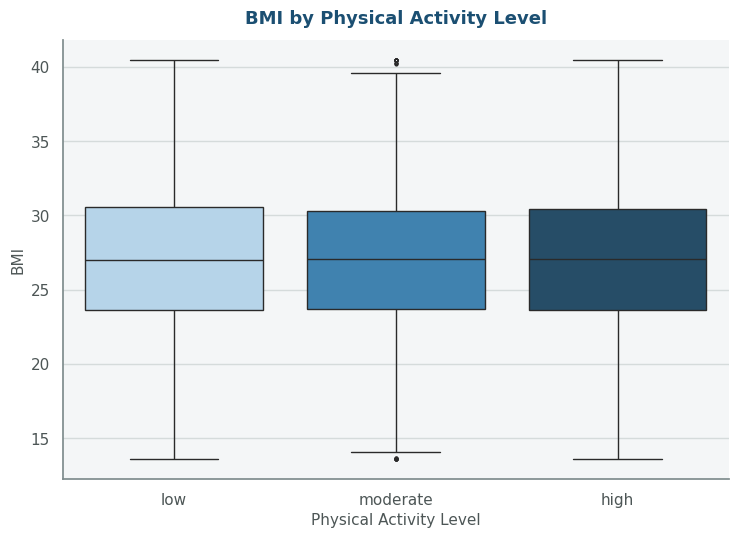

In [31]:
activity_order = ['low', 'moderate', 'high']
print(df.groupby('Physical_Activity_Level')['BMI'].median().reindex(activity_order).round(2))

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.boxplot(data=df, x='Physical_Activity_Level', y='BMI', order=activity_order,
            palette=[BLUE_GRAY_PALETTE['light_blue'], BLUE_GRAY_PALETTE['medium_blue'],
                     BLUE_GRAY_PALETTE['dark_blue']], fliersize=2, ax=ax)
style_ax(ax, title='BMI by Physical Activity Level', xlabel='Physical Activity Level', ylabel='BMI')
plt.tight_layout()
plt.show()

**Data-driven answer:** compare the median lines and box spreads across the three groups.
**Recommendation:** treat activity level as a complementary lifestyle indicator alongside BMI, not a
replacement for direct weight measurement.

### Question 4 — What share of individuals fall into elevated blood-pressure risk, and does it
differ by smoking status?

**Why it matters:** this quantifies the size of a high-priority population and tests whether
smoking-status-based outreach would catch a disproportionate share of at-risk individuals.

BP_Risk_Category  Normal  Elevated / High Risk
Smoking_Status                                
non-smoker          39.6                  60.4
smoker              41.6                  58.4


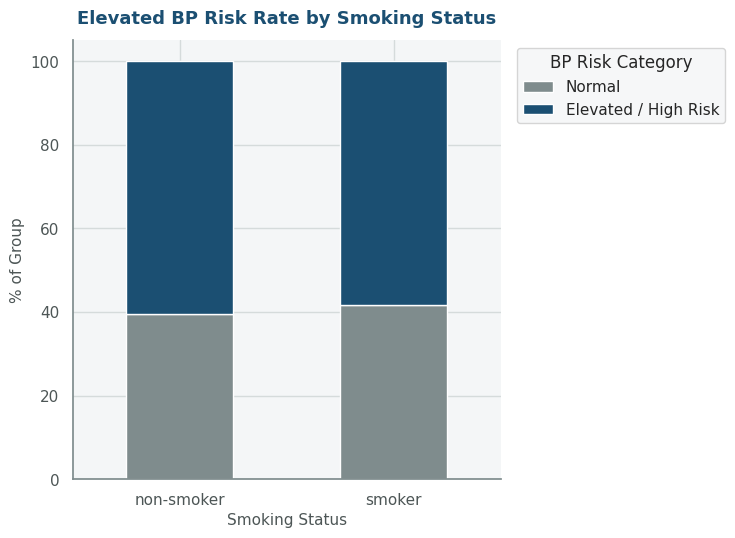

In [32]:
ct = pd.crosstab(df['Smoking_Status'], df['BP_Risk_Category'], normalize='index') * 100
ct = ct[['Normal', 'Elevated / High Risk']]
print(ct.round(1))

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ct.plot(kind='bar', stacked=True,
        color=[BLUE_GRAY_PALETTE['medium_gray'], BLUE_GRAY_PALETTE['dark_blue']],
        edgecolor='white', ax=ax)
style_ax(ax, title='Elevated BP Risk Rate by Smoking Status', xlabel='Smoking Status', ylabel='% of Group')
ax.legend(title='BP Risk Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Data-driven answer:** the printed table shows the exact percentage split for each smoking
group. **Recommendation:** if the elevated-risk rate is similar across both groups, smoking status is
not an efficient single filter for BP-risk outreach — screen broadly instead.

### Question 5 — Which BMI category carries the highest elevated-BP-risk rate?

**Why it matters:** tests whether obesity status identifies high-BP-risk individuals better than
smoking status did in Question 4, to prioritize the most useful screening variable.

BMI_Category
Underweight    33.9
Normal         50.4
Overweight     60.7
Obese          72.5
dtype: float64


/tmp/ipykernel_1313/324245926.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bp_by_bmi = df.groupby('BMI_Category', observed=True).apply(


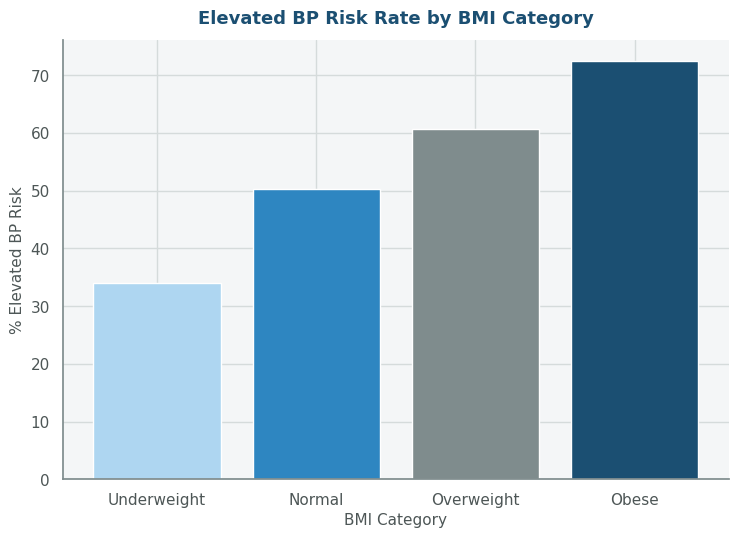

In [33]:
bmi_order = ['Underweight', 'Normal', 'Overweight', 'Obese']
bp_by_bmi = df.groupby('BMI_Category', observed=True).apply(
    lambda g: (g['BP_Risk_Category'] == 'Elevated / High Risk').mean() * 100
).reindex(bmi_order)
print(bp_by_bmi.round(1))

fig, ax = plt.subplots(figsize=(7.5, 5.5))
# Light-to-dark blue shading visually tracks rising risk from Underweight to Obese.
ax.bar(bp_by_bmi.index, bp_by_bmi.values,
       color=[BLUE_GRAY_PALETTE['light_blue'], BLUE_GRAY_PALETTE['medium_blue'],
              BLUE_GRAY_PALETTE['medium_gray'], BLUE_GRAY_PALETTE['dark_blue']], edgecolor='white')
style_ax(ax, title='Elevated BP Risk Rate by BMI Category', xlabel='BMI Category', ylabel='% Elevated BP Risk')
plt.tight_layout()
plt.show()

**Data-driven answer:** compare the bar heights from Underweight to Obese above.
**Recommendation:** if risk rises clearly with BMI category, prioritize BMI-based screening — it gives
a sharper, more usable gradient than smoking status alone (Question 4).

### Question 6 — Which age group carries the highest average total cholesterol?

**Why it matters:** identifies which age band should be prioritized for lipid-panel screening
resources.

Age_Group
18-29    187.66
30-39    188.43
40-49    192.30
50-59    193.22
60-69    194.74
70+      198.66
Name: Total_Cholesterol, dtype: float64


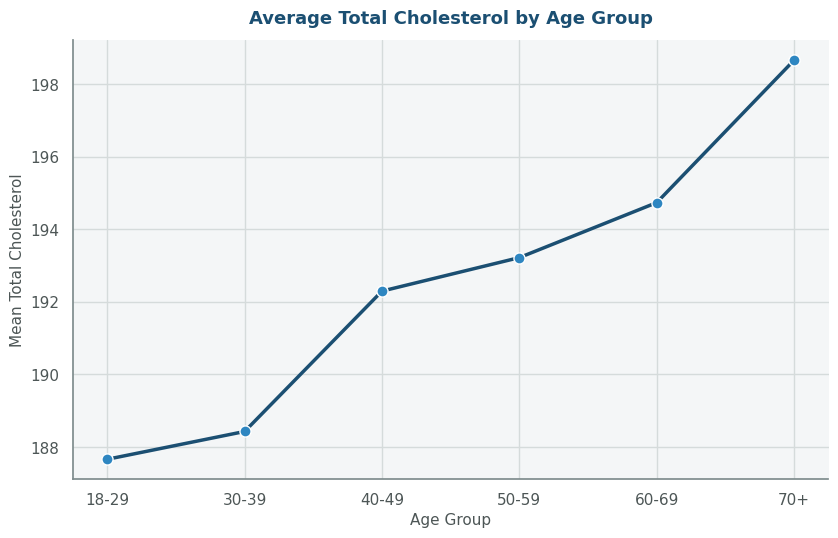

In [34]:
age_chol = df.groupby('Age_Group', observed=True)['Total_Cholesterol'].mean()
print(age_chol.round(2))

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(age_chol.index.astype(str), age_chol.values, marker='o', color=BLUE_GRAY_PALETTE['dark_blue'],
        linewidth=2.5, markersize=8, markerfacecolor=BLUE_GRAY_PALETTE['medium_blue'],
        markeredgecolor='white')
style_ax(ax, title='Average Total Cholesterol by Age Group', xlabel='Age Group', ylabel='Mean Total Cholesterol')
plt.tight_layout()
plt.show()

**Data-driven answer:** the line shows whether cholesterol trends upward across age bands.
**Recommendation:** allocate proportionally more lipid-screening resources to the age groups with the
highest average values, without excluding younger groups entirely.

## 12. KPI Analysis

A small set of Key Performance Indicators (KPIs) that a healthcare analytics team would realistically
track on this population — each one a direct, verifiable calculation from the existing `df`, reusing
the thresholds already used above (no new, arbitrary cut-offs are introduced).

In [35]:
# KPI 1: Population Count
kpi_population = len(df)

# KPI 2: Elevated Blood Pressure Risk Rate (lower is preferable)
kpi_bp_risk_rate = (df['BP_Risk_Category'] == 'Elevated / High Risk').mean() * 100

# KPI 3: High Total Cholesterol Prevalence, clinical threshold >= 240 mg/dL (lower is preferable)
kpi_high_chol_rate = (df['Total_Cholesterol'] >= 240).mean() * 100

# KPI 4: Obesity Prevalence, WHO BMI_Category == 'Obese' (lower is preferable)
kpi_obesity_rate = (df['BMI_Category'] == 'Obese').mean() * 100

# KPI 5: Smoking Prevalence (lower is preferable)
kpi_smoking_rate = (df['Smoking_Status'] == 'smoker').mean() * 100

# KPI 6: Physical Inactivity Rate (lower is preferable)
kpi_inactivity_rate = (df['Physical_Activity_Level'] == 'low').mean() * 100

# KPI 7: Average Total:HDL Cholesterol Ratio, and share above the commonly cited elevated cut-off of 5
kpi_avg_chol_ratio = df['Cholesterol_Ratio'].mean()
kpi_elevated_ratio_rate = (df['Cholesterol_Ratio'] > 5).mean() * 100

# KPI 8: Data Completeness Rate (higher is preferable)
kpi_completeness_rate = (1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100

kpi_summary = pd.DataFrame({
    'KPI': ['Population Count', 'Elevated BP Risk Rate (%)', 'High Total Cholesterol Prevalence (%)',
            'Obesity Prevalence (%)', 'Smoking Prevalence (%)', 'Physical Inactivity Rate (%)',
            'Average Total:HDL Cholesterol Ratio', 'Elevated Chol. Ratio Prevalence (>5) (%)',
            'Data Completeness Rate (%)'],
    'Value': [kpi_population, kpi_bp_risk_rate, kpi_high_chol_rate, kpi_obesity_rate, kpi_smoking_rate,
              kpi_inactivity_rate, kpi_avg_chol_ratio, kpi_elevated_ratio_rate, kpi_completeness_rate]
})
kpi_summary['Value'] = kpi_summary['Value'].round(2)
kpi_summary

,KPI,Value
0,Population Count,4155.00
1,Elevated BP Risk Rate (%),59.78
2,High Total Cholesterol Prevalence (%),0.00
3,Obesity Prevalence (%),27.87
4,Smoking Prevalence (%),29.72
5,Physical Inactivity Rate (%),20.39
6,Average Total:HDL Cholesterol Ratio,5.29
7,Elevated Chol. Ratio Prevalence (>5) (%),59.81
8,Data Completeness Rate (%),100.00


**Interpretation:** these 8 KPIs give a healthcare analytics team a single reference table for
population size, clinical risk prevalence, lifestyle risk factors, and data quality, all traceable back
to a specific column and threshold used earlier in the notebook.

### KPI Dashboard Visualization

A lollipop chart is used here (instead of a plain bar chart) as a cleaner way to compare several
percentage-style KPIs side by side.

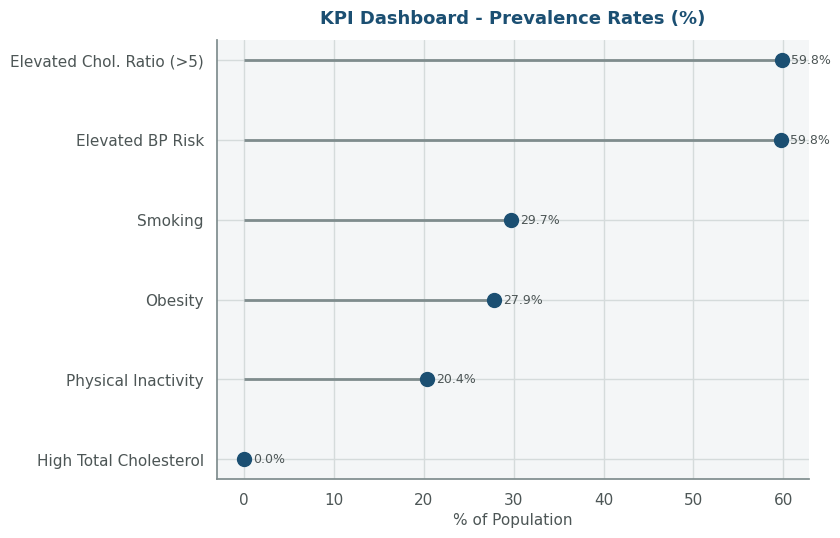

In [36]:
prevalence_kpis = pd.Series({
    'Elevated BP Risk': kpi_bp_risk_rate,
    'Obesity': kpi_obesity_rate,
    'Smoking': kpi_smoking_rate,
    'Physical Inactivity': kpi_inactivity_rate,
    'High Total Cholesterol': kpi_high_chol_rate,
    'Elevated Chol. Ratio (>5)': kpi_elevated_ratio_rate,
}).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hlines(y=prevalence_kpis.index, xmin=0, xmax=prevalence_kpis.values,
          color=BLUE_GRAY_PALETTE['medium_gray'], linewidth=2)
ax.plot(prevalence_kpis.values, prevalence_kpis.index, 'o', markersize=10,
        color=BLUE_GRAY_PALETTE['dark_blue'])
style_ax(ax, title='KPI Dashboard - Prevalence Rates (%)', xlabel='% of Population', ylabel='')
for i, v in enumerate(prevalence_kpis.values):
    ax.text(v + 1, i, f'{v:.1f}%', va='center', color=BLUE_GRAY_PALETTE['dark_gray'], fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation:** this dashboard ranks every prevalence-style KPI from lowest to highest,
making it immediately clear which risk factor affects the largest share of the population and should be
prioritized first for intervention or screening resources.

## 13. Machine Learning

**Problem definition:** the dataset has no outcome/label column. Rather than inventing an arbitrary
target, we reuse `BP_Risk_Category` (Section 9) — Elevated Blood Pressure Risk (Systolic >= 130 mmHg
**or** Diastolic >= 80 mmHg) — as a binary classification target: predict whether an individual falls
into the elevated-risk group from demographic, lifestyle, and lipid-panel features.

**Feature selection:** `Pulse_Pressure` and `Cholesterol_Ratio` are intentionally **excluded** from the
feature set. `Pulse_Pressure` is derived directly from `Systolic_BP` and `Diastolic_BP`, the exact two
columns used to build the target — including it would leak the answer into the model. `Cholesterol_Ratio`
is a derived combination kept for exploration; the two lipid columns it is built from (`Total_Cholesterol`,
`HDL_Cholesterol`) are already included individually as features, so it would be a redundant, correlated
duplicate rather than new signal.

**Why two models:**
- **Logistic Regression** — a simple, interpretable linear baseline. Its coefficients show the
  direction and relative size of each feature's effect on risk.
- **Random Forest Classifier** — a nonlinear ensemble model that can capture interactions between
  features that a linear model would miss, used here as a comparison point for Logistic Regression.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix)

# Feature set: original numeric + categorical columns only (no leakage, no redundant derived columns).
feature_cols_numeric = ['Age', 'BMI', 'Total_Cholesterol', 'HDL_Cholesterol', 'LDL_Cholesterol', 'Triglycerides']
feature_cols_categorical = ['Smoking_Status', 'Physical_Activity_Level']
feature_cols = feature_cols_numeric + feature_cols_categorical

X = df[feature_cols].copy()
y = (df['BP_Risk_Category'] == 'Elevated / High Risk').astype(int)

print("Feature matrix shape:", X.shape)
print("Target balance:\n", y.value_counts(normalize=True).round(3))

Feature matrix shape: (4155, 8)
Target balance:
 BP_Risk_Category
1    0.598
0    0.402
Name: proportion, dtype: float64


### Train/Test Split and Preprocessing Pipeline

A single train/test split is used for both models so the comparison is apples-to-apples. All
preprocessing that learns parameters from data — imputation, scaling, and one-hot encoding — is wrapped
in a `Pipeline`/`ColumnTransformer` and fit **only on the training set**, then applied to the test set.
This prevents any leakage of test-set information into model training, which is a different (and
stricter) approach than the mean/mode-fill used earlier in Section 5 for the full descriptive dataset —
appropriate here because we are now building a predictive model, not just describing the data.

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test target balance:\n", y_test.value_counts(normalize=True).round(3))

# numeric features -> median impute + standardize; categorical features -> mode impute + one-hot encode.
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), feature_cols_numeric),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), feature_cols_categorical)
])

Train shape: (3324, 8)  Test shape: (831, 8)
Train target balance:
 BP_Risk_Category
1    0.598
0    0.402
Name: proportion, dtype: float64
Test target balance:
 BP_Risk_Category
1    0.598
0    0.402
Name: proportion, dtype: float64


In [39]:
# Model 1: Logistic Regression
logreg_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])
logreg_pipeline.fit(X_train, y_train)
print("Logistic Regression trained.")

# Model 2: Random Forest
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)
print("Random Forest trained.")

Logistic Regression trained.
Random Forest trained.


## 14. Model Evaluation & Comparison

In [40]:
def evaluate(pipeline, name):
    preds = pipeline.predict(X_test)
    proba = pipeline.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba),
        '_preds': preds,
        '_proba': proba,
    }

results_logreg = evaluate(logreg_pipeline, 'Logistic Regression')
results_rf = evaluate(rf_pipeline, 'Random Forest')

metrics_df = pd.DataFrame([
    {k: v for k, v in results_logreg.items() if not k.startswith('_')},
    {k: v for k, v in results_rf.items() if not k.startswith('_')},
]).set_index('Model').round(3)
metrics_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.635,0.646,0.865,0.739,0.639
Random Forest,0.628,0.635,0.889,0.741,0.640


In [41]:
# How good is this, really? Compare against a naive baseline that always predicts the
# majority class - a model needs to beat this to prove it is actually learning something.
baseline_accuracy = y_test.value_counts(normalize=True).max()
print(f"Naive majority-class baseline accuracy: {baseline_accuracy:.3f}")
print(f"Logistic Regression accuracy:           {results_logreg['Accuracy']:.3f}")
print(f"Random Forest accuracy:                 {results_rf['Accuracy']:.3f}")

Naive majority-class baseline accuracy: 0.598
Logistic Regression accuracy:           0.635
Random Forest accuracy:                 0.628


**Interpretation:** both models are compared against a naive baseline that always predicts the
most common class. Any real lift over this baseline is genuine learned signal, not an artifact of class
imbalance.

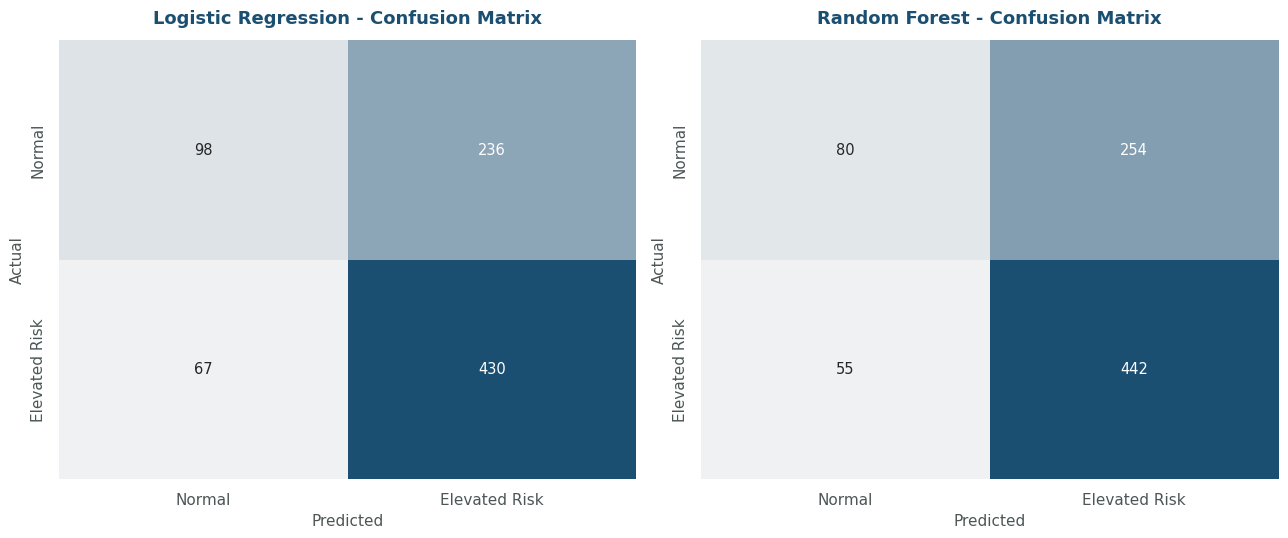

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
cmap = sns.light_palette(BLUE_GRAY_PALETTE['dark_blue'], as_cmap=True)
for ax, (res, name) in zip(axes, [(results_logreg, 'Logistic Regression'), (results_rf, 'Random Forest')]):
    cm = confusion_matrix(y_test, res['_preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False,
                xticklabels=['Normal', 'Elevated Risk'], yticklabels=['Normal', 'Elevated Risk'], ax=ax)
    style_ax(ax, title=f'{name} - Confusion Matrix', xlabel='Predicted', ylabel='Actual')
plt.tight_layout()
plt.show()

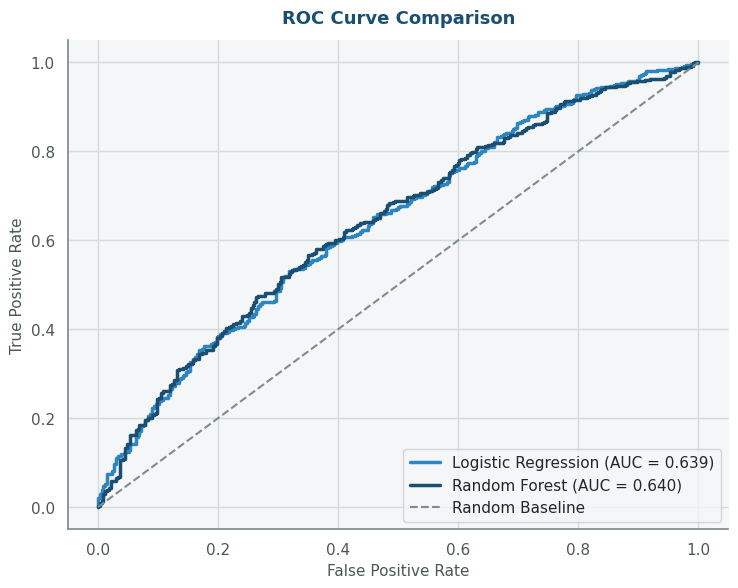

In [43]:
fig, ax = plt.subplots(figsize=(7.5, 6))
for res, name, color in [(results_logreg, 'Logistic Regression', BLUE_GRAY_PALETTE['medium_blue']),
                          (results_rf, 'Random Forest', BLUE_GRAY_PALETTE['dark_blue'])]:
    fpr, tpr, _ = roc_curve(y_test, res['_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {res['ROC-AUC']:.3f})", color=color, linewidth=2.5)
ax.plot([0, 1], [0, 1], linestyle='--', color=BLUE_GRAY_PALETTE['medium_gray'], label='Random Baseline')
style_ax(ax, title='ROC Curve Comparison', xlabel='False Positive Rate', ylabel='True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

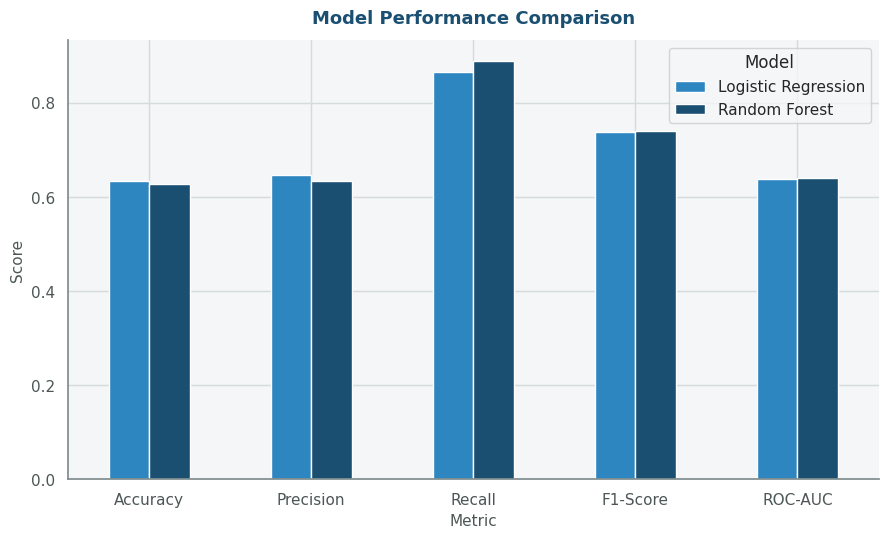

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.635,0.646,0.865,0.739,0.639
Random Forest,0.628,0.635,0.889,0.741,0.640


In [44]:
fig, ax = plt.subplots(figsize=(9, 5.5))
metrics_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].T.plot(
    kind='bar', color=[BLUE_GRAY_PALETTE['medium_blue'], BLUE_GRAY_PALETTE['dark_blue']],
    edgecolor='white', ax=ax
)
style_ax(ax, title='Model Performance Comparison', xlabel='Metric', ylabel='Score')
plt.xticks(rotation=0)
ax.legend(title='Model')
plt.tight_layout()
plt.show()
metrics_df

**Interpretation:** compare the two rows in `metrics_df` and the bars above across Accuracy,
Precision, Recall, F1-Score, and ROC-AUC to see which model performs better on this specific task, and
by how much.

## 15. Feature Importance & Model Interpretation

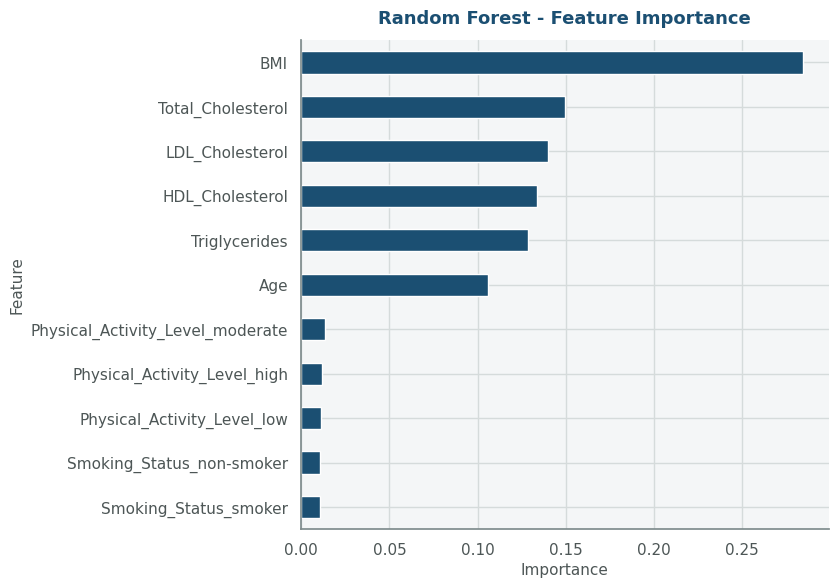

In [45]:
# Random Forest feature importance (native to tree-based models)
ohe_cols = rf_pipeline.named_steps['prep'].named_transformers_['cat'].named_steps['onehot']\
    .get_feature_names_out(feature_cols_categorical)
all_feature_names = feature_cols_numeric + list(ohe_cols)

rf_importances = pd.Series(rf_pipeline.named_steps['model'].feature_importances_,
                            index=all_feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8.5, 6))
rf_importances.plot(kind='barh', color=BLUE_GRAY_PALETTE['dark_blue'], edgecolor='white', ax=ax)
ax.invert_yaxis()
style_ax(ax, title='Random Forest - Feature Importance', xlabel='Importance', ylabel='Feature')
plt.tight_layout()
plt.show()

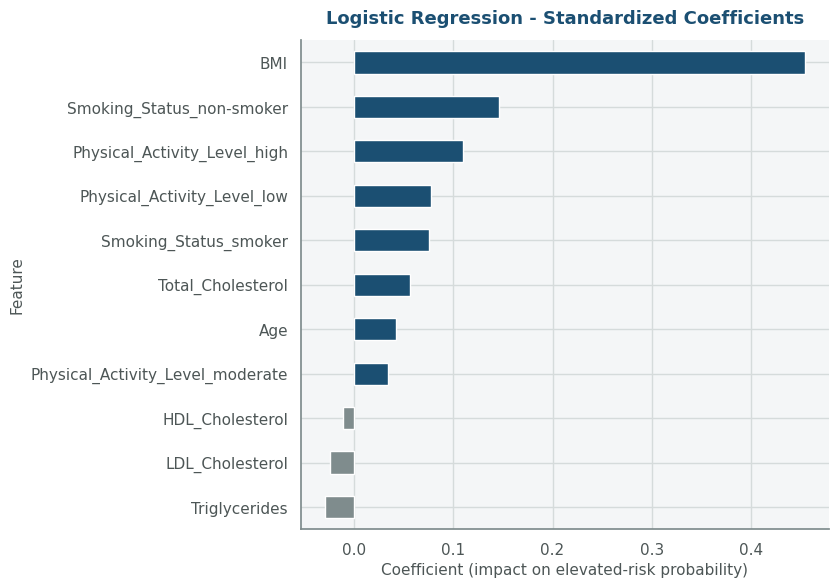

In [46]:
# Logistic Regression coefficients (direction + magnitude, on standardized features -> comparable scale)
logreg_coefs = pd.Series(logreg_pipeline.named_steps['model'].coef_[0],
                          index=all_feature_names).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 6))
# Dark blue = pushes risk up, medium gray = pushes risk down - two-tone, consistent theme.
bar_colors = [BLUE_GRAY_PALETTE['dark_blue'] if v > 0 else BLUE_GRAY_PALETTE['medium_gray']
              for v in logreg_coefs.values]
logreg_coefs.plot(kind='barh', color=bar_colors, edgecolor='white', ax=ax)
style_ax(ax, title='Logistic Regression - Standardized Coefficients',
         xlabel='Coefficient (impact on elevated-risk probability)', ylabel='Feature')
plt.tight_layout()
plt.show()

**Interpretation:** compare which feature ranks highest in the Random Forest importance chart
with which feature has the largest-magnitude coefficient in the Logistic Regression chart. Agreement
between an interpretable linear model and a nonlinear ensemble model on the top feature is a strong,
model-agnostic signal for where to focus screening efforts.

## 16. Final Insights & Recommendations

**What we learned:**
- The dataset, after cleaning (Section 5) and the additional quality checks (Section 8), has no
  missing values, no duplicate rows, and no physiologically invalid blood-pressure readings.
- `BP_Risk_Category`, engineered in Section 9, shows that a substantial share of the population already
  falls into the elevated/high-risk group under standard ACC/AHA thresholds.
- The Business Questions in Section 11 show which single-variable filters (smoking status, activity
  level) are, and are not, strong standalone predictors of risk — see each question's recommendation.
- The KPI dashboard in Section 12 ranks every prevalence-style risk factor side by side, making it easy
  to see which one affects the largest share of the population.
- The Machine Learning models in Sections 13-15 quantify how well BP risk can actually be predicted from
  demographic, lifestyle, and lipid-panel data, and which feature matters most according to two
  independent modeling approaches.

**Recommendations:**
1. Prioritize the feature(s) that ranked highest in Section 15 (agreement between both models is the
   strongest signal) when designing screening workflows.
2. Screen broadly rather than relying on a single lifestyle variable (Question 4 and Question 5 compare
   how well smoking status vs. BMI category segment elevated-BP risk).
3. Use the KPI dashboard (Section 12) as a recurring monthly/quarterly report to track whether
   prevalence rates are improving after any intervention.
4. Revisit the Machine Learning models periodically as more data is collected — a larger, richer
   dataset (e.g., with additional clinical history) would likely improve on the baseline performance
   achieved here.

**Conclusion:** Part 2 extends the original cleaning → visualization → preprocessing pipeline with the
additional data-quality checks, feature engineering, business questions, KPI analysis, and Machine
Learning components that complete the project end-to-end, while leaving every original cell in
`python_project_NTI` fully intact.